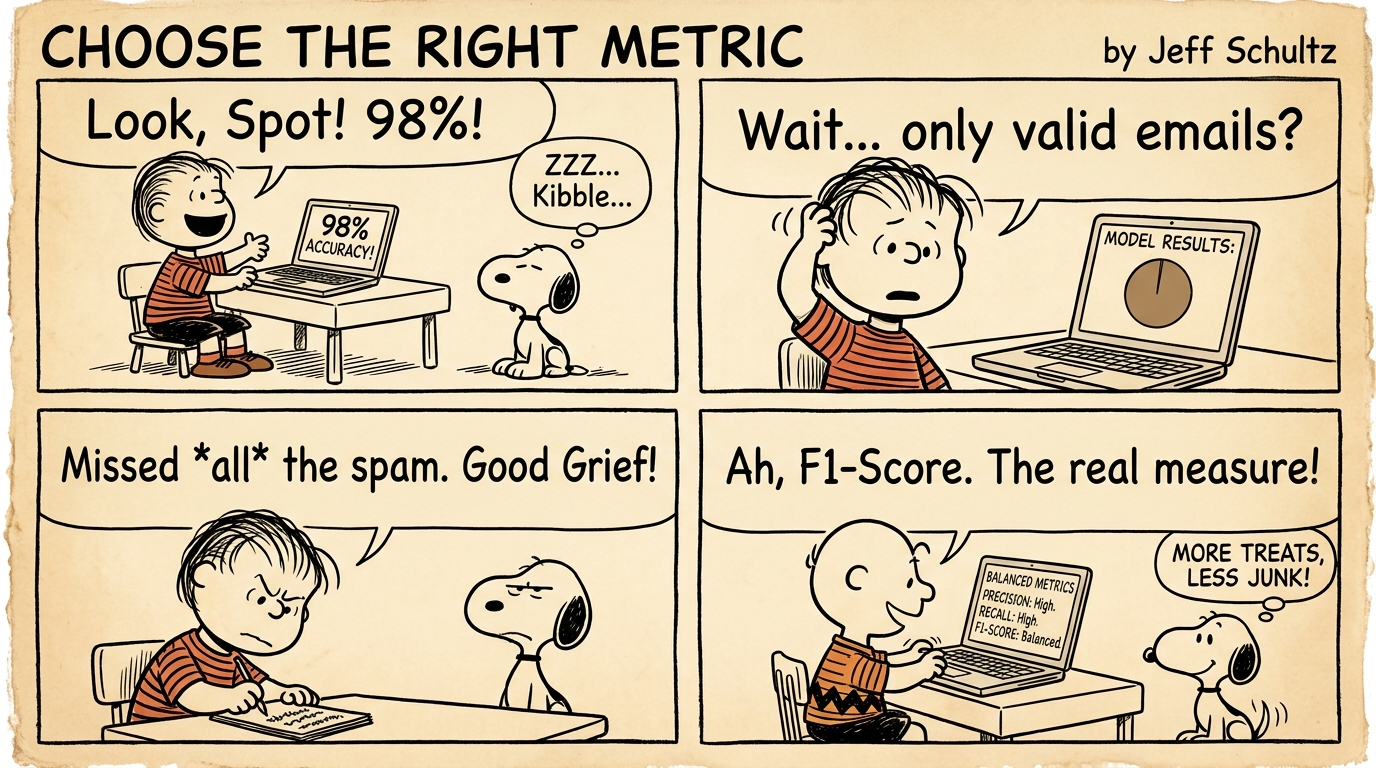

# When is a classifier good enough?
## Binary classification metrics, imbalance, and logistic regression

A model is not useful merely because it is “accurate.” Its usefulness depends on **which mistakes it makes** and what those mistakes cost. In this activity, you will build common binary classification metrics from counts, use them to diagnose a logistic regression model on imbalanced data, and choose a decision threshold for a specific use case.

By the end of the activity, you should be able to:

1. construct the four counts in a binary confusion matrix;
2. implement accuracy, precision, recall, specificity, F1, and balanced accuracy from scratch;
3. explain why accuracy can be misleading when the positive class is rare;
4. explain how a logistic regression probability becomes a class prediction;
5. describe the precision–recall tradeoff created by changing the threshold; and
6. recommend a metric and threshold that match the consequences of false positives and false negatives.


Part 4 contains optional extensions. It is fine not to finish them during class.

Work with a partner if desired. Discuss each prompt before running the next cell. Complete every **TODO** and replace each response placeholder with your reasoning. If you are working in a pair, switch driver and navigator after Part 1.

## 0. Setup and decision framing

The positive class in this notebook is a rare harmful event that may require investigation. A logistic regression model will estimate the probability that each case belongs to this class.

A word such as “positive” does not mean “good.” It means that the event coded as 1 occurred. Always identify what 1 means before interpreting a metric.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics as sk_metrics
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 486
pd.set_option("display.precision", 3)

### What makes an error costly?

Suppose class 1 means a serious condition is present.

- A **false positive** sends a condition-free case for an unnecessary follow-up.
- A **false negative** misses a case that actually has the condition.

**Response 0.** In a first-stage screening system, which error would you try hardest to reduce? Would your answer necessarily be the same for a final, invasive procedure? Explain in 2–3 sentences.

**Response:** _Write your answer here before continuing._

## 1. Build binary classification metrics from scratch

Begin with ten cases small enough to check by hand. Here, 1 is the positive class and 0 is the negative class.

In [ ]:
toy_true = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1])
toy_pred = np.array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

toy_cases = pd.DataFrame({
    "case": np.arange(1, len(toy_true) + 1),
    "actual": toy_true,
    "predicted": toy_pred,
})
toy_cases

### Task 1 — Count the four possible outcomes

| | Predicted 0 | Predicted 1 |
|---|---:|---:|
| **Actually 0** | true negative (TN) | false positive (FP) |
| **Actually 1** | false negative (FN) | true positive (TP) |

Complete the function using Boolean comparisons. NumPy treats True as 1 and False as 0, so summing a Boolean array counts the cases satisfying a condition.

The function must return values in the order **TN, FP, FN, TP**.

In [ ]:
def confusion_counts(y_true, y_pred):
    """Return the binary confusion counts in the order TN, FP, FN, TP."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    # TODO 1a: Count actual 0, predicted 0.
    tn = ...

    # TODO 1b: Count actual 0, predicted 1.
    fp = ...

    # TODO 1c: Count actual 1, predicted 0.
    fn = ...

    # TODO 1d: Count actual 1, predicted 1.
    tp = ...

    return int(tn), int(fp), int(fn), int(tp)

In [ ]:
# This check gives quick feedback without revealing the implementation.
toy_counts = confusion_counts(toy_true, toy_pred)
assert toy_counts == (6, 1, 2, 1), f"Check the four conditions. You returned {toy_counts}."

tn, fp, fn, tp = toy_counts
toy_confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actually 0", "actually 1"],
    columns=["predicted 0", "predicted 1"],
)
toy_confusion

**Response 1.** The words “false positive” and “false negative” can be confusing. Describe each error in this example without using either of those two phrases.

- **FP = 1 means:** _Write your interpretation._
- **FN = 2 means:** _Write your interpretation._

### Task 2 — Turn the counts into metrics

Each metric answers a different question. Notice which cases appear in each denominator.

| Metric | Formula | Question answered |
|---|---|---|
| Accuracy | $(TP+TN)/(TP+TN+FP+FN)$ | What fraction of all predictions were correct? |
| Precision | $TP/(TP+FP)$ | When the model predicted 1, how often was it right? |
| Recall (sensitivity) | $TP/(TP+FN)$ | Of the actual 1s, what fraction did the model find? |
| Specificity | $TN/(TN+FP)$ | Of the actual 0s, what fraction did the model clear? |
| F1 | $2(\text{precision})(\text{recall})/(\text{precision}+\text{recall})$ | Are precision and recall both reasonably high? |
| Balanced accuracy | $(\text{recall}+\text{specificity})/2$ | How well did the model perform across both actual classes? |

Complete every function below. Call confusion_counts inside each function so the connection to the four counts remains visible.

The supplied safe_ratio function returns 0 when its denominator is 0. This matches one common software convention, but remember that the mathematical ratio is undefined in that case.

In [ ]:
def safe_ratio(numerator, denominator):
    """Return numerator / denominator, using 0.0 when denominator is zero."""
    return 0.0 if denominator == 0 else numerator / denominator


def accuracy(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    # TODO 2a: correct predictions / all predictions
    return ...


def precision(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    # TODO 2b: true positives / all predicted positives
    return ...


def recall(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    # TODO 2c: true positives / all actual positives
    return ...


def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    # TODO 2d: true negatives / all actual negatives
    return ...


def f1(y_true, y_pred):
    precision_value = precision(y_true, y_pred)
    recall_value = recall(y_true, y_pred)
    # TODO 2e: harmonic mean of precision and recall
    return ...


def balanced_accuracy(y_true, y_pred):
    recall_value = recall(y_true, y_pred)
    specificity_value = specificity(y_true, y_pred)
    # TODO 2f: mean of performance on the two actual classes
    return ...

In [ ]:
# Run these checks after completing all six functions.
expected = {
    "accuracy": 0.7,
    "precision": 0.5,
    "recall": 1 / 3,
    "specificity": 6 / 7,
    "f1": 0.4,
    "balanced_accuracy": (1 / 3 + 6 / 7) / 2,
}

observed = {
    "accuracy": accuracy(toy_true, toy_pred),
    "precision": precision(toy_true, toy_pred),
    "recall": recall(toy_true, toy_pred),
    "specificity": specificity(toy_true, toy_pred),
    "f1": f1(toy_true, toy_pred),
    "balanced_accuracy": balanced_accuracy(toy_true, toy_pred),
}

for name, expected_value in expected.items():
    assert np.isclose(observed[name], expected_value), (
        f"Check {name}: expected {expected_value:.3f}, got {observed[name]}"
    )

pd.Series(observed, name="toy value").to_frame()

**Response 2.** The toy classifier has 70% accuracy but only 33% recall.

1. How can both statements be true?
2. If a missed positive is the most harmful error, which number better communicates the problem?

**Response:** _Write 2–4 sentences._

In [ ]:
# This helper uses your functions to make later comparisons compact.
def metric_summary(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "predicted_positive": fp + tp,
        "accuracy": accuracy(y_true, y_pred),
        "precision": precision(y_true, y_pred),
        "recall": recall(y_true, y_pred),
        "specificity": specificity(y_true, y_pred),
        "f1": f1(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy(y_true, y_pred),
    }


# Verify your implementation against scikit-learn only after your tests pass.
assert np.isclose(observed["accuracy"], sk_metrics.accuracy_score(toy_true, toy_pred))
assert np.isclose(observed["precision"], sk_metrics.precision_score(toy_true, toy_pred))
assert np.isclose(observed["recall"], sk_metrics.recall_score(toy_true, toy_pred))
assert np.isclose(observed["f1"], sk_metrics.f1_score(toy_true, toy_pred))
print("Your metric functions agree with scikit-learn on the toy data.")

### Task 3 — Match the metric to the decision

For each setting, choose a **primary** metric and justify it. More than one metric may still need monitoring.

1. A screening test sends possible cases to a safe follow-up test. Missing the condition is much worse than an extra follow-up.
2. A spam system permanently deletes messages labeled as spam. Deleting a legitimate message is much worse than leaving some spam in the inbox.
3. A roughly balanced prediction problem has similar costs for the two kinds of errors.
4. Positive cases are rare, and stakeholders want one summary that becomes low when either precision or recall is low.

**Response 3:**

1. _Metric and reason_
2. _Metric and reason_
3. _Metric and reason_
4. _Metric and reason_

## 2. Diagnose logistic regression on imbalanced data

We will now create a synthetic rare-event dataset. Synthetic data let us control the class balance and focus on evaluation. Class 1 is the event that should trigger an alert.

In [ ]:
# This function simulates a binary classification problem with a rare positive class. 
X, y = make_classification(
    n_samples=5000,
    n_features=12,
    n_informative=6,
    n_redundant=2,
    weights=[0.96, 0.04],
    class_sep=1.7,
    flip_y=0.01,
    random_state=RANDOM_STATE,
)

class_counts = pd.Series(y).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "count": class_counts,
    "proportion": class_counts / len(y),
})
class_distribution.index = ["class 0", "class 1"]
display(class_distribution)

ax = class_counts.plot.bar(color=["#4C78A8", "#E45756"], rot=0)
ax.set(xticklabels=["class 0", "class 1"], ylabel="number of cases", title="The positive class is rare")
plt.show()

Before fitting a model, calculate the approximate accuracy of a rule that always predicts class 0. What would its recall for class 1 be?

**Prediction:** _Write both values here, then check them below._

In [ ]:
# Keep a final test set untouched while we explore thresholds on validation data.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
)
logistic_model.fit(X_train, y_train)

print(f"train size: {len(y_train):,}; positive rate: {y_train.mean():.3%}")
print(f"validation size: {len(y_val):,}; positive rate: {y_val.mean():.3%}")
print(f"test size: {len(y_test):,}; positive rate: {y_test.mean():.3%}")

### Task 4 — Compare two decision rules

Logistic regression returns a score between 0 and 1 for class 1. A common default predicts 1 when that score is at least 0.50.

Complete the two prediction rules, then use your metric_summary function to compare them on the validation set.

In [ ]:
val_scores = logistic_model.predict_proba(X_val)[:, 1]

# TODO 4a: Make an integer array of zeros with the same shape as y_val.
always_negative = ...

# TODO 4b: Predict 1 when val_scores is at least 0.50 and 0 otherwise.
pred_at_050 = ...

baseline_comparison = pd.DataFrame({
    "always predict 0": metric_summary(y_val, always_negative),
    "logistic, threshold 0.50": metric_summary(y_val, pred_at_050),
}).T

baseline_comparison

**Response 4.** Use the counts as well as the rates in your answer.

1. Why is the always-negative rule a useful baseline even though it is not a useful classifier?
2. Which metric makes its failure most obvious?
3. At a threshold of 0.50, what is logistic regression doing well, and what is it doing poorly?

**Response:** _Write 3–5 sentences._

## 3. Change the threshold, change the errors

Logistic regression produces scores; the threshold turns those scores into actions.

- Lower threshold → more predicted positives → usually higher recall and more false positives.
- Higher threshold → fewer predicted positives → usually higher precision and more false negatives.

These directions are typical, but a finite sample can produce ties or small irregularities. Metrics at one threshold do not describe every possible decision rule.

Without running code, predict what will happen to each quantity if the threshold changes from 0.50 to 0.10:

- number of predicted positives;
- false positives;
- false negatives;
- precision; and
- recall.

**Prediction:** _Write your predicted directions. Mark any metric whose direction is not logically guaranteed._

### Task 5 — Build a threshold table

For each candidate threshold:

1. turn the validation scores into 0/1 predictions;
2. evaluate the predictions with your metric_summary function; and
3. store the threshold with the resulting metrics.

The first iteration is outlined. Complete the two TODOs.

In [ ]:
thresholds = np.array([
    0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05,
    0.075, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60,
    0.70, 0.80, 0.90,
])
threshold_rows = []

for threshold in thresholds:
    # TODO 5a: Convert val_scores to 0/1 predictions at this threshold.
    predictions = ...

    # TODO 5b: Get the metric dictionary for these predictions.
    row = ...
    row["threshold"] = threshold
    threshold_rows.append(row)

threshold_results = (
    pd.DataFrame(threshold_rows)
    .set_index("threshold")
    .sort_index()
)

threshold_results[[
    "predicted_positive", "FP", "FN", "precision", "recall",
    "specificity", "f1", "balanced_accuracy"
]]

In [ ]:
# Plot the rates; keep the counts visible in the table above.
fig, ax = plt.subplots(figsize=(9, 5))
for metric in ["precision", "recall", "specificity", "f1"]:
    ax.plot(threshold_results.index, threshold_results[metric], marker="o", label=metric)

ax.set(
    xlabel="decision threshold",
    ylabel="metric value",
    ylim=(-0.02, 1.02),
    title="No threshold is best for every objective",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Task 6 — Recommend thresholds for two different deployments

Use the validation table and plot. Give an exact threshold from the table and cite at least two metrics or counts.

**Deployment A: safety screen.** Missing an event is very costly. The team requires recall of at least 0.80 and, among thresholds meeting that requirement, wants to avoid unnecessary investigations.

**Recommendation A:** _Threshold, evidence, and tradeoff._

**Deployment B: limited review capacity.** Investigators can review only a small number of alerts. The team values precision but will reject a policy that finds almost none of the events.

**Recommendation B:** _State a threshold, evidence, tradeoff, and what minimum recall you consider acceptable._

**Response 5.** Why should the two deployments use different thresholds even though they use the same fitted logistic regression model?

**Response:** _Write 2–4 sentences._

### Task 7 — Use the test set once

A threshold chosen after repeatedly examining test results is tuned to the test set. That makes the final estimate too optimistic. Choose a threshold from the validation results above, enter it below, and evaluate it once on the untouched test set.

In [ ]:
# TODO 7: Replace None with one threshold selected in Task 6.
chosen_threshold = None

if chosen_threshold is None:
    print("Choose a validation-set threshold before evaluating the test set.")
else:
    test_scores = logistic_model.predict_proba(X_test)[:, 1]
    test_predictions = (test_scores >= chosen_threshold).astype(int)
    display(pd.Series(metric_summary(y_test, test_predictions), name="test result").to_frame())

**Response 6.** Compare the test result with the validation result at your chosen threshold. Are they identical? Explain why some difference is expected, even when the workflow is correct.

**Response:** _Write 2–3 sentences._

---

## 4. Optional extensions

Complete these if time permits. They deepen the same ideas without introducing a different classifier. If the class wants to explore imbalance methods, jump directly to Extension C; it uses the results from Parts 1–3 and does not depend on Extensions A or B.

### Extension A — ROC and precision–recall curves

A curve summarizes many thresholds rather than committing to one.

- The **ROC curve** plots recall against the false-positive rate. ROC AUC summarizes ranking across the two actual classes.
- The **precision–recall curve** focuses on the positive predictions and actual positives. Average precision (AP) summarizes this curve.

When positives are rare, a small false-positive rate can still create many false alerts. A precision–recall curve often makes that operational issue easier to see. AP also depends on prevalence, so comparisons across datasets with different class balances require care. Neither curve chooses a threshold or encodes the real cost of an error.

In [ ]:
fpr_curve, tpr_curve, _ = sk_metrics.roc_curve(y_val, val_scores)
curve_precision, curve_recall, _ = sk_metrics.precision_recall_curve(y_val, val_scores)

roc_auc = sk_metrics.roc_auc_score(y_val, val_scores)
average_precision = sk_metrics.average_precision_score(y_val, val_scores)
prevalence = y_val.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_curve, tpr_curve, label=f"logistic regression (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="random ranking")
axes[0].set(xlabel="false-positive rate", ylabel="recall", title="ROC curve")
axes[0].legend()

axes[1].plot(curve_recall, curve_precision, label=f"logistic regression (AP={average_precision:.3f})")
axes[1].axhline(prevalence, linestyle="--", color="gray", label=f"prevalence={prevalence:.3f}")
axes[1].set(xlabel="recall", ylabel="precision", title="Precision–recall curve")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Extension response A.** Is the model better than random at ranking cases? Which curve better communicates the quality of its positive alerts in this imbalanced setting? Support your answer with the plot and at least one number.

**Response:** _Write 2–4 sentences._

### Extension B — Class-weighted logistic regression

The default fit treats every training case equally. Setting class_weight to balanced gives errors on the rare class more influence during fitting. This changes the fitted logistic regression model; changing a threshold changes only how an already-fitted model is used.

Class weighting is not automatically better. It often trades precision for recall, and its probability scores may need calibration before being interpreted as real-world probabilities.

In [ ]:
# TODO B1: Add class_weight="balanced" to LogisticRegression.
weighted_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        # class_weight=...,
    ),
)
weighted_model.fit(X_train, y_train)

weighted_val_scores = weighted_model.predict_proba(X_val)[:, 1]
weighted_pred_at_050 = (weighted_val_scores >= 0.50).astype(int)

weight_comparison = pd.DataFrame({
    "unweighted, threshold 0.50": metric_summary(y_val, pred_at_050),
    "weighted, threshold 0.50": metric_summary(y_val, weighted_pred_at_050),
}).T
weight_comparison

**Extension response B.** After adding the class weight, which confusion counts changed most? Describe the precision–recall tradeoff. Is class weighting automatically preferable to selecting a different threshold for the unweighted model?

**Response:** _Write 3–5 sentences._

### Extension C — Undersampling and SMOTE with logistic regression

Both methods change the **training data** before fitting logistic regression:

- **Random undersampling** keeps all training positives but randomly removes training negatives until the classes have equal counts. It can throw away useful information.
- **SMOTE** creates synthetic training positives between nearby positive cases until the classes have equal counts. It uses distances, so we scale the features before applying it. Synthetic cases may be unhelpful when the positive class is noisy or overlaps strongly with the negative class.

Keep the validation and test sets at their original class proportions. Resampling them would make the evaluation unlike the population where the model will be used. We use the imbalanced-learn Pipeline so the sampler runs during fit on the training data and is skipped during prediction.

This extension uses imbalanced-learn, included in this folder's pyproject.toml. If you are using a separate notebook environment that lacks it, run %pip install imbalanced-learn in a new cell, restart the kernel, and rerun the notebook.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as SamplingPipeline
from imblearn.under_sampling import RandomUnderSampler

# This small demonstration touches training data only. Scaling matters for
# SMOTE's nearest-neighbor distances; the fitted models below use pipelines.
X_train_scaled = StandardScaler().fit_transform(X_train)
training_counts = {"original": np.bincount(y_train, minlength=2)}

for name, sampler in {
    "random undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
}.items():
    _, y_sampled = sampler.fit_resample(X_train_scaled, y_train)
    training_counts[name] = np.bincount(y_sampled, minlength=2)

pd.DataFrame(training_counts, index=["class 0", "class 1"]).T

Compared with the unweighted logistic regression model at threshold 0.50, which method do you expect to have more false positives: undersampling, SMOTE, or neither? Explain your prediction before running the next cell. Remember that balancing the training data does not guarantee better validation results.

**Prediction:** _Write 1–2 sentences._

In [ ]:
# The imbalanced-learn pipeline fits the scaler and sampler on X_train only.
# The sampler is skipped when predict() sees X_val.
undersampling_model = SamplingPipeline([
    ("scale", StandardScaler()),
    ("sample", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("logistic", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

smote_model = SamplingPipeline([
    ("scale", StandardScaler()),
    ("sample", SMOTE(random_state=RANDOM_STATE)),
    ("logistic", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

undersampling_model.fit(X_train, y_train)
smote_model.fit(X_train, y_train)

resampling_comparison = pd.DataFrame({
    "no resampling": metric_summary(y_val, pred_at_050),
    "random undersampling": metric_summary(y_val, undersampling_model.predict(X_val)),
    "SMOTE": metric_summary(y_val, smote_model.predict(X_val)),
}).T

resampling_comparison[[
    "TN", "FP", "FN", "TP", "accuracy", "precision", "recall", "f1"
]]

**Extension response C.** Which method finds the most actual positives? Which produces the most false alarms? Compare both to the original logistic regression model using counts and rates. Then explain why you should compare these results on the original, imbalanced validation set rather than on the resampled training set.

**Response:** _Write 3–5 sentences. A higher recall alone does not settle the deployment choice._

## Final decision memo

Write a short recommendation to a stakeholder. Your answer should be understandable to someone who knows the application but does not know the metric formulas.

Include:

1. what class 1 represents;
2. which error is more costly in your chosen deployment;
3. the primary metric and why it matches that cost;
4. your recommended threshold and supporting validation evidence;
5. the tradeoff your recommendation accepts; and
6. one limitation of evaluating on synthetic data.

**Memo:** _Write approximately 100–150 words._

## Takeaways

- Start with the positive class and the consequences of the two errors, not with a favorite metric.
- Accuracy can be dominated by the majority class.
- Precision asks about predicted positives; recall asks about actual positives. Their denominators matter.
- F1 balances precision and recall, but it does not include true negatives or real error costs.
- A logistic regression score becomes a decision only after choosing a threshold.
- Threshold selection, class weighting, and resampling answer related but different questions.
- Choose policies on training/validation data, then use the test set once for a final estimate.
- Always report the confusion counts alongside summary metrics when the consequences matter.